In [1]:
import pandas as pd
import numpy as np 
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.models as models
from torch.utils.data import DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import json
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [2]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")# df["time_sec"] = pd.to_datetime(df["time"]).dt.strftime("%H:%M:%S")

In [3]:
df["time_sec"] = (pd.to_datetime(df["time"]))

# convert it to 0-300
df["time_sec"] = (
    df.groupby("subject_experiment_id")["time_sec"]
    .transform(lambda x:
        (x - x.min())
        .dt.total_seconds()
        .astype(int)
    )
)
df.head()

,group,time,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id,time_sec
0,group01,2026-05-08 10:40:43.047895,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
1,group01,2026-05-08 10:40:43.195317,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
2,group01,2026-05-08 10:40:43.295405,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,0
3,group01,2026-05-08 10:40:43.395835,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
df[['attention', 'heart_rate', 'gender', 'age']].isna().sum()

attention     0
heart_rate    0
gender        0
age           0
dtype: int64

In [5]:
sensor_cols = [
    col for col in df.columns
    if (
        "sensor" in col.lower()
        or "acceleration" in col.lower()
        or "gyro" in col.lower()
        or "rotation" in col.lower()
        or "heart" in col.lower()
        or "light" in col.lower()
        or "accel" in col.lower()
    )]
    # if (
    # "gyro" in col.lower()

    # )]

In [6]:
df[sensor_cols].isna().sum()

samsung_rotation_vector value0_mean                    0
samsung_rotation_vector value0_std                     6
samsung_rotation_vector value1_mean                    0
samsung_rotation_vector value1_std                     6
samsung_rotation_vector value2_mean                    0
samsung_rotation_vector value2_std                     6
samsung_rotation_vector value3_mean                    0
samsung_rotation_vector value3_std                     6
samsung_rotation_vector value4_mean                    0
samsung_rotation_vector value4_std                     6
lsm6dso_gyroscope value0_mean                          0
lsm6dso_gyroscope value0_std                           6
lsm6dso_gyroscope value1_mean                          0
lsm6dso_gyroscope value1_std                           6
lsm6dso_gyroscope value2_mean                          0
lsm6dso_gyroscope value2_std                           6
samsung_linear_acceleration_sensor value0_mean         0
samsung_linear_acceleration_sen

In [7]:
# fill with mean the remaining nan values
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())
df[sensor_cols] = df[sensor_cols].astype(np.float32)

In [75]:
metadata_cols = ["experiment", "group", 'subject_id', "gender", "age"]

# aggregate sensor features
df_sensor = df.groupby(["subject_experiment_id", "time_sec"])[sensor_cols].mean().reset_index()

# aggregate attention target
df_attention = df.groupby(["subject_experiment_id", "time_sec"])["attention"].mean().reset_index()

# merge sensors + target
df_sensor = df_sensor.merge(df_attention, on=["subject_experiment_id", "time_sec"])

# keep metadata
df_meta = df.groupby(["subject_experiment_id", "time_sec"])[metadata_cols].first().reset_index()

df_sensors_metadata = df_meta.merge(df_sensor, on=["subject_experiment_id", "time_sec"])

# keep only 1 frame per second (the first)
df_sensors_metadata = (df.sort_values("time")
      .groupby(["subject_experiment_id", "time_sec"])
      .first()
      .reset_index())

In [76]:
class DipserSensorDataset(Dataset):
    def __init__(self, df, sensor_cols):
        self.df = df.reset_index(drop=True)
        self.sensor_cols = sensor_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
    
        x = torch.tensor(
            row[self.sensor_cols].values.astype(np.float32)
        )
        y = torch.tensor(row["attention"], dtype=torch.float32)
    
        return x, y, idx

### Train Test Split

In [77]:
subject_df = df_sensors_metadata[['subject_id', 'gender']].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df['gender'],
    random_state=42)

# further break temp for balanced val and test
val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
    stratify=temp_sub['gender'],
    random_state=42)

train_subjects = train_sub['subject_id']
val_subjects = val_sub['subject_id']
test_subjects = test_sub['subject_id']

train_df = df_sensors_metadata[df_sensors_metadata["subject_id"].isin(train_subjects)]
val_df  = df_sensors_metadata[df_sensors_metadata["subject_id"].isin(val_subjects)]
test_df  = df_sensors_metadata[df_sensors_metadata["subject_id"].isin(test_subjects)]

### Normalize Sensor Features

In [78]:
scaler = StandardScaler()

train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
val_df[sensor_cols] = scaler.transform(val_df[sensor_cols])
test_df[sensor_cols]  = scaler.transform(test_df[sensor_cols])

/scratch-local/cfragkiadakis.22726488/ipykernel_135071/1846154732.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols])
/scratch-local/cfragkiadakis.22726488/ipykernel_135071/1846154732.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[sensor_cols] = scaler.transform(val_df[sensor_cols])
/scratch-local/cfragkiadakis.22726488/ipykernel_135071/1846154732.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [79]:
train_df.shape, val_df.shape, test_df.shape

((77300, 68), (16444, 68), (18010, 68))

In [80]:
train_dataset = DipserSensorDataset(train_df, sensor_cols)
val_dataset = DipserSensorDataset(val_df, sensor_cols)
test_dataset  = DipserSensorDataset(test_df, sensor_cols)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

In [81]:
class SensorModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [82]:
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    preds_all = []
    labels_all = []

    pbar = tqdm(loader, desc="Training", leave=False)

    for x, labels, _ in pbar:
        x, labels = x.to(device), labels.to(device)

        preds = model(x)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [83]:
def evaluate(model, loader):
    model.eval()

    preds_all = []
    labels_all = []
    inference_times = []

    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for imgs, labels, _ in pbar:
            imgs = imgs.to(device)

            start = time.time()
            preds = model(imgs)
            torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)

            preds = preds.cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(labels.numpy())

    mae = mean_absolute_error(labels_all, preds_all)
    rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return mae, rmse, np.mean(inference_times)

In [84]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [85]:
name = "initial_2"
model_path = f"models/Sensors Static/{name}_sensors_baseline.pt"
model_results = f"results/Sensors Static/{name}_sensors_results.json"
model_figs = f"figs/Sensors Static/{name}_sensors_training_curves.png"

In [86]:
# criterion = nn.MSELoss() # minimize RMSE
criterion = nn.L1Loss() # minimize MAE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SensorModel(input_dim=len(sensor_cols)).to(device)
#optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min', factor=0.3, patience=3)

In [87]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 100
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    # --- store metrics ---
    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)

    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)

    # --- logging ---
    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")


    # --- scheduler ---
    scheduler.step(val_mae)

    # --- early stopping ---
    stop = early_stopping.step(val_mae, model, epoch)
    best_epoch = early_stopping.best_epoch 
    
    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()

print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.4472
Train MAE: 0.4473 | Train RMSE: 0.7087
Val MAE: 0.3667 | Val RMSE: 0.4633



Epoch 2
Train Loss: 0.3097
Train MAE: 0.3097 | Train RMSE: 0.4132
Val MAE: 0.3532 | Val RMSE: 0.4480



Epoch 3
Train Loss: 0.2958
Train MAE: 0.2958 | Train RMSE: 0.3946
Val MAE: 0.3534 | Val RMSE: 0.4478
EarlyStopping counter: 1/7



Epoch 4
Train Loss: 0.2875
Train MAE: 0.2875 | Train RMSE: 0.3844
Val MAE: 0.3544 | Val RMSE: 0.4508
EarlyStopping counter: 2/7



Epoch 5
Train Loss: 0.2812
Train MAE: 0.2812 | Train RMSE: 0.3772
Val MAE: 0.3553 | Val RMSE: 0.4471
EarlyStopping counter: 3/7



Epoch 6
Train Loss: 0.2760
Train MAE: 0.2760 | Train RMSE: 0.3718
Val MAE: 0.3568 | Val RMSE: 0.4530
EarlyStopping counter: 4/7



Epoch 7
Train Loss: 0.2681
Train MAE: 0.2681 | Train RMSE: 0.3632
Val MAE: 0.3631 | Val RMSE: 0.4569
EarlyStopping counter: 5/7



Epoch 8
Train Loss: 0.2658
Train MAE: 0.2658 | Train RMSE: 0.3606
Val MAE: 0.3625 | Val RMSE: 0.4595
EarlyStopping counter: 6/7



Epoch 9
Train Loss: 0.2648
Train MAE: 0.2648 | Train RMSE: 0.3600
Val MAE: 0.3672 | Val RMSE: 0.4622
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 63.80942130088806


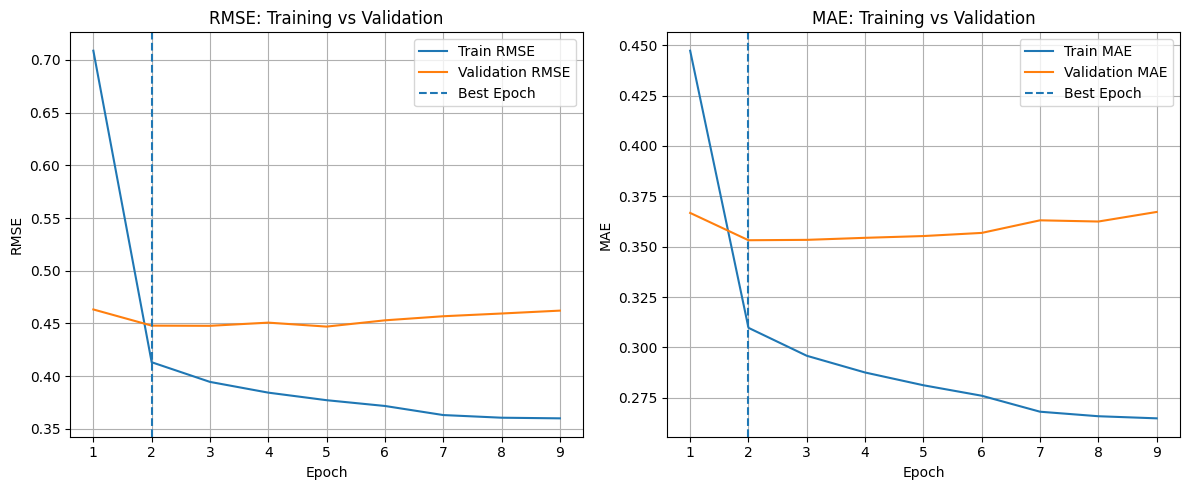

In [88]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- RMSE plot ---
ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

# --- MAE plot ---
ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle='--', label='Best Epoch')
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [89]:
def collect_predictions(model, df, loader):

    model.eval()

    results = []

    all_preds = []

    total_time = 0
    total_samples = 0

    with torch.no_grad():

        pbar = tqdm(loader, desc="Evaluating")

        for imgs, labels, idx in pbar:

            imgs = imgs.to(device)

            start = time.time()

            preds = model(imgs)

            end = time.time()

            batch_time = end - start

            total_time += batch_time
            total_samples += imgs.size(0)

            preds = preds.squeeze().cpu().numpy()

            all_preds.extend(preds)

            for i in range(len(preds)):

                row = df.iloc[idx[i].item()]

                results.append({
                    "pred": float(preds[i]),
                    "true": float(labels[i].item()),
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)

    mae = np.mean(np.abs(results_df["true"] - results_df["pred"]))

    rmse = np.sqrt(np.mean((results_df["true"] - results_df["pred"])**2))

    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return (
        np.array(all_preds),
        results_df,
        mae,
        rmse,
        latency_per_batch,
        latency_per_sample
    )

In [90]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))

    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group

    return group_mae, worst_group, gap
    
def replace_nan(d, value=None):
    if isinstance(d, dict):
        return {
            k: replace_nan(v, value)
            for k, v in d.items()
        }
    if isinstance(d, float) and math.isnan(d):
        return value
    return d
    

def compute_fairness_metrics(results_df):
    metrics = {}

    # ---- Gender ----
    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")

    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    # ---- Age ----
    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])

    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")

    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics

In [91]:
# name = "initial"
# model_path = f"models/Sensors Static/{name}_sensors_baseline.pt"
# model_results = f"results/Sensors Static/{name}_sensors_results.json"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SensorModel(input_dim=len(sensor_cols)).to(device)
model.load_state_dict(torch.load(model_path))
model.eval()

/scratch-local/cfragkiadakis.22726488/ipykernel_135071/2386953689.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


SensorModel(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [92]:
# add fairness columns to compute metrics
preds, results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
results = {
    "mae": round(float(best_mae),4),
    "rmse": round(float(best_rmse),4),
    "latency_per_batch": round(float(best_latency_batch),4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000),4),
    "fairness": fairness_metrics
}

clean_results = replace_nan(results, value=None)

with open(model_results, "w") as f:
    json.dump(clean_results, f, indent=4)

Evaluating: 100%|██████████| 141/141 [00:05<00:00, 25.01it/s]
/scratch-local/cfragkiadakis.22726488/ipykernel_135071/1208367613.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.22726488/ipykernel_135071/1208367613.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(lambda x: np.mean(np.abs(x["true"] - x["pred"])))
/scratch-local/cfragkiadakis.227264

In [93]:
print('MAE:', results['mae'])

MAE: 0.3503


In [94]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

MAE per gender:
 {'female': 0.33618, 'male': 0.38735}

Worst-group MAE: 0.38735
Gap: 0.05117


In [95]:
print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per age:
 {'(13, 17]': 0.40355, '(17, 20]': 0.24054, '(20, 22]': 0.33681, '(22, 26]': 0.39692, '(26, 44]': 0.34455}

Worst-group MAE: 0.40355
Gap: 0.16301


In [96]:
mean_pred = train_df["attention"].mean()

baseline_mae = (
    test_df["attention"] - mean_pred
).abs().mean()

print(mean_pred)
print(baseline_mae)

2.929249676584735
0.32466260227715943


In [97]:
print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

2.170689
366.59943
3.0757499
2.7161617


In [102]:
from sklearn.metrics import r2_score
preds = np.clip(preds, 1, 5)
print(r2_score(test_df['attention'], preds))

-0.04417471160709607


### Try with XGBoost

In [58]:
sensor_cols

['samsung_rotation_vector value0_mean',
 'samsung_rotation_vector value0_std',
 'samsung_rotation_vector value1_mean',
 'samsung_rotation_vector value1_std',
 'samsung_rotation_vector value2_mean',
 'samsung_rotation_vector value2_std',
 'samsung_rotation_vector value3_mean',
 'samsung_rotation_vector value3_std',
 'samsung_rotation_vector value4_mean',
 'samsung_rotation_vector value4_std',
 'lsm6dso_gyroscope value0_mean',
 'lsm6dso_gyroscope value0_std',
 'lsm6dso_gyroscope value1_mean',
 'lsm6dso_gyroscope value1_std',
 'lsm6dso_gyroscope value2_mean',
 'lsm6dso_gyroscope value2_std',
 'samsung_linear_acceleration_sensor value0_mean',
 'samsung_linear_acceleration_sensor value0_std',
 'samsung_linear_acceleration_sensor value1_mean',
 'samsung_linear_acceleration_sensor value1_std',
 'samsung_linear_acceleration_sensor value2_mean',
 'samsung_linear_acceleration_sensor value2_std',
 'opt3007_light value0_mean',
 'opt3007_light value0_std',
 'heart_rate',
 'heart_rate_std',
 'accel_

In [103]:
sensor_columns = ['heart_rate', 'heart_rate_std', 'accel_magnitude_mean',
 'accel_magnitude_std',
 'gyro_magnitude_mean',
 'gyro_magnitude_std']

sensor_columns = sensor_cols

In [104]:
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

X_train = train_df[sensor_columns]
y_train = train_df["attention"]

X_val = val_df[sensor_columns]
y_val = val_df["attention"]

X_test = test_df[sensor_columns]
y_test = test_df["attention"]

In [105]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42)

In [106]:
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [107]:
preds = xgb_model.predict(X_test)

In [108]:
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

print(preds.min())
print(preds.max())
print(preds.mean())
print(preds.std())

MAE : 0.32672164407059723
RMSE: 0.4285301662778661
R2  : -0.03599630903763629
2.4646587
4.2971606
2.9904447
0.2197389


In [109]:
importance_df = pd.DataFrame({
    "feature": sensor_columns,
    "importance": xgb_model.feature_importances_})

importance_df = importance_df.sort_values("importance", ascending=False)
importance_df.head()

,feature,importance
22,opt3007_light value0_mean,0.089371
4,samsung_rotation_vector value2_mean,0.085385
7,samsung_rotation_vector value3_std,0.076248
6,samsung_rotation_vector value3_mean,0.061611
24,heart_rate,0.056067
